# ============================================
# 0. SETUP & DATA LOADING
# ============================================

## Purpose
Load and combine all monthly crime CSV files, convert the Month field to datetime, and prepare the dataset for analysis.

## Summary
- Multiple CSVs loaded and concatenated  
- Dataset contains 353,570 rows × 12 columns  
- Month converted to datetime and set as index  
- Ready for full EDA and modelling


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load all CSVs
data_path = Path("../data")
csv_files = list(data_path.rglob("*.csv"))

dfs = [pd.read_csv(f) for f in csv_files]
crime_df = pd.concat(dfs, ignore_index=True)

# Convert Month → datetime
crime_df["Month"] = pd.to_datetime(crime_df["Month"])

# Set index
crime_df = crime_df.set_index("Month")


# ============================================
# 1. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

## Purpose
Understand the structure, quality, and behaviour of the dataset before modelling.  
This includes data types, missing values, duplicates, distributions, and early insights.

---


## 1.1 Initial Data Review

### Summary of Findings
- 353,570 rows × 12 columns  
- Crime ID and Last outcome category share identical missingness (~11.6%)  
- Geographic fields have ~1.4% missingness (expected “No Location” suppression)  
- Context column is fully missing and removed  
- Dataset spans 36 months (Jul 2023 → Jun 2026)  
- Memory usage ~32 MB

The dataset is structurally sound and ready for deeper analysis.


In [42]:
print(crime_df.head())
print(crime_df.sample(5))
print(crime_df.shape)
print(crime_df.dtypes)
print(crime_df.info())
print(crime_df.memory_usage(deep=True))


                                                     Crime ID  \
Month                                                           
2023-07-01                                                NaN   
2023-07-01  cfb1c13be199c8129c1b2b9c69e801ea5d3cac67be1e65...   
2023-07-01  96cd5fb582b5bb7b4012242963f7244d215a751de2ea94...   
2023-07-01  d9cc161c0e5505f18708626fdde48cb7802e6ba2114322...   
2023-07-01  1e17a1bdedd237575e0b10ddd6f737f8a81cfca56366d0...   

                     Reported by          Falls within  Longitude   Latitude  \
Month                                                                          
2023-07-01  Norfolk Constabulary  Norfolk Constabulary   1.074614  51.989271   
2023-07-01  Norfolk Constabulary  Norfolk Constabulary   0.414958  51.628580   
2023-07-01  Norfolk Constabulary  Norfolk Constabulary   1.034813  52.750330   
2023-07-01  Norfolk Constabulary  Norfolk Constabulary   1.028209  52.745283   
2023-07-01  Norfolk Constabulary  Norfolk Constabulary   1.06820

## 1.2 Data Quality Review

### Missing Values
- Crime ID: 11.59%  
- Last outcome category: 11.59%  
- Longitude / Latitude / LSOA fields: 1.43%  
- Context: 100% (removed)

### Duplicates
- 8,129 potential duplicates detected  
- Mostly due to repeated records with identical fields

### Numeric Fields
- Longitude/Latitude valid  
- No impossible coordinates  
- No negative values

The dataset is clean enough to proceed without heavy preprocessing.


In [43]:
print(crime_df.isnull().sum())
print(crime_df.isnull().mean() * 100)
print(crime_df.duplicated().sum())
print(crime_df.describe(include='number'))


Crime ID                  40986
Reported by                   0
Falls within                  0
Longitude                  5078
Latitude                   5078
Location                      0
LSOA code                  5078
LSOA name                  5078
Crime type                    0
Last outcome category     40986
Context                  353570
dtype: int64
Crime ID                  11.592047
Reported by                0.000000
Falls within               0.000000
Longitude                  1.436208
Latitude                   1.436208
Location                   0.000000
LSOA code                  1.436208
LSOA name                  1.436208
Crime type                 0.000000
Last outcome category     11.592047
Context                  100.000000
dtype: float64
29383
           Longitude       Latitude  Context
count  348492.000000  348492.000000      0.0
mean        1.122539      52.449159      NaN
std         0.429929       0.269839      NaN
min        -5.306914      50.469170   

## 1.3 Summary Statistics

### Key Findings
- 36 unique months  
- 14 crime types  
- 15 outcome categories  
- 2 police forces (Norfolk & Suffolk)  
- 2,606 unique LSOAs  
- Location field has extremely high cardinality (16,511 unique values)

The dataset is rich, structured, and suitable for both descriptive and predictive analysis.


In [44]:
print(crime_df.describe(include='all'))
print(crime_df.nunique())

                                                 Crime ID  \
count                                              312584   
unique                                             312584   
top     cfb1c13be199c8129c1b2b9c69e801ea5d3cac67be1e65...   
freq                                                    1   
mean                                                  NaN   
std                                                   NaN   
min                                                   NaN   
25%                                                   NaN   
50%                                                   NaN   
75%                                                   NaN   
max                                                   NaN   

                 Reported by          Falls within      Longitude  \
count                 353570                353570  348492.000000   
unique                     2                     2            NaN   
top     Norfolk Constabulary  Norfolk Constabulary          

## 1.4 Crime Type Distribution

### Top Crime Types
- Violence and sexual offences (42.15%)  
- Anti-social behaviour (11.59%)  
- Criminal damage and arson (9.31%)  
- Shoplifting (8.27%)  
- Public order (7.00%)

### Observations
- Demand is dominated by violent offences and ASB  
- Lower-volume categories represent specialist or opportunistic offences  


                               Count  Percent
Crime type                                   
Violence and sexual offences  149047    42.15
Anti-social behaviour          40986    11.59
Criminal damage and arson      32934     9.31
Shoplifting                    29232     8.27
Public order                   24739     7.00
Other theft                    23188     6.56
Burglary                       11301     3.20
Vehicle crime                  10698     3.03
Other crime                    10093     2.85
Drugs                           9320     2.64
Possession of weapons           4412     1.25
Bicycle theft                   3658     1.03
Theft from the person           2018     0.57
Robbery                         1944     0.55


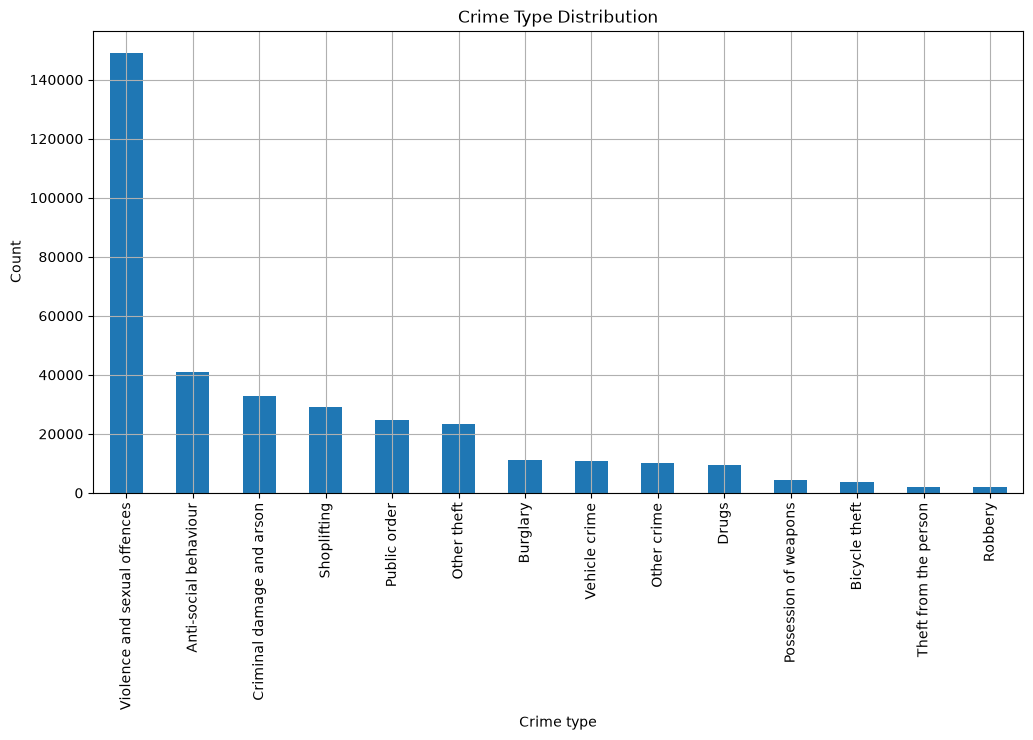

In [45]:
crime_type_counts = crime_df['Crime type'].value_counts()
crime_type_percent = (crime_type_counts / len(crime_df)) * 100

crime_type_summary = pd.DataFrame({
    'Count': crime_type_counts,
    'Percent': crime_type_percent.round(2)
})

print(crime_type_summary)

plt.figure(figsize=(12,6))
crime_type_counts.plot(kind='bar')
plt.title("Crime Type Distribution")
plt.ylabel("Count")
plt.grid(True)
plt.show()


## 1.5 Outcome Category Distribution

### Top Outcomes
- Unable to prosecute suspect (40.61%)  
- No suspect identified (21.91%)  
- Court result unavailable (7.60%)

### Observations
- Over 60% of outcomes fall into non-prosecution categories  
- Reflects investigative attrition and evidential challenges  


                                                     Count  Percent
Last outcome category                                              
Unable to prosecute suspect                         143576    40.61
Investigation complete; no suspect identified        77482    21.91
Court result unavailable                             26880     7.60
Action to be taken by another organisation           13708     3.88
Local resolution                                     11988     3.39
Under investigation                                  11234     3.18
Status update unavailable                             9503     2.69
Awaiting court outcome                                7632     2.16
Offender given a caution                              4490     1.27
Further investigation is not in the public inte...    2054     0.58
Suspect charged as part of another case               1600     0.45
Further action is not in the public interest          1407     0.40
Formal action is not in the public interest     

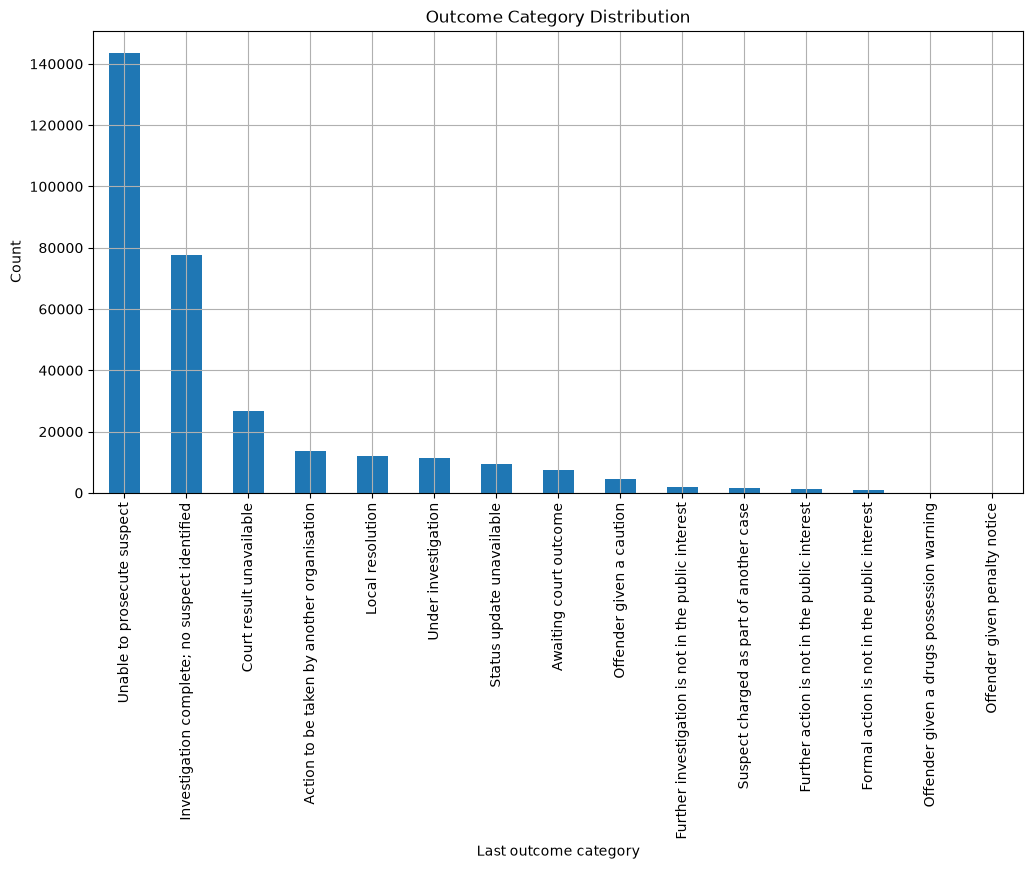

In [46]:
outcome_counts = crime_df['Last outcome category'].value_counts()
outcome_percent = (outcome_counts / len(crime_df)) * 100

outcome_summary = pd.DataFrame({
    'Count': outcome_counts,
    'Percent': outcome_percent.round(2)
})

print(outcome_summary)

plt.figure(figsize=(12,6))
outcome_counts.plot(kind='bar')
plt.title("Outcome Category Distribution")
plt.ylabel("Count")
plt.grid(True)
plt.show()


## 1.6 Geographic (LSOA) Distribution

### Top LSOAs
- Norwich 017B  
- Ipswich 007G  
- Norwich 014A  
- Great Yarmouth 005C  
- West Suffolk 011A  

### Observations
- High-demand LSOAs correspond to urban centres  
- Rural/out-of-region LSOAs show extremely low counts due to suppression  


LSOA name
Norwich 017B                         7097
Ipswich 007G                         4980
Norwich 014A                         4156
Great Yarmouth 005C                  3656
West Suffolk 011A                    2414
Norwich 017A                         2310
Great Yarmouth 006E                  2270
Norwich 014D                         2253
Breckland 005B                       2160
King's Lynn and West Norfolk 011H    2155
Name: count, dtype: int64 LSOA name
Milton Keynes 005B             1
Peterborough 001A              1
Peterborough 021E              1
Shropshire 023F                1
Southwark 004E                 1
Thanet 005A                    1
Thurrock 003B                  1
West Northamptonshire 017B     1
Wiltshire 031A                 1
Windsor and Maidenhead 005G    1
Name: count, dtype: int64


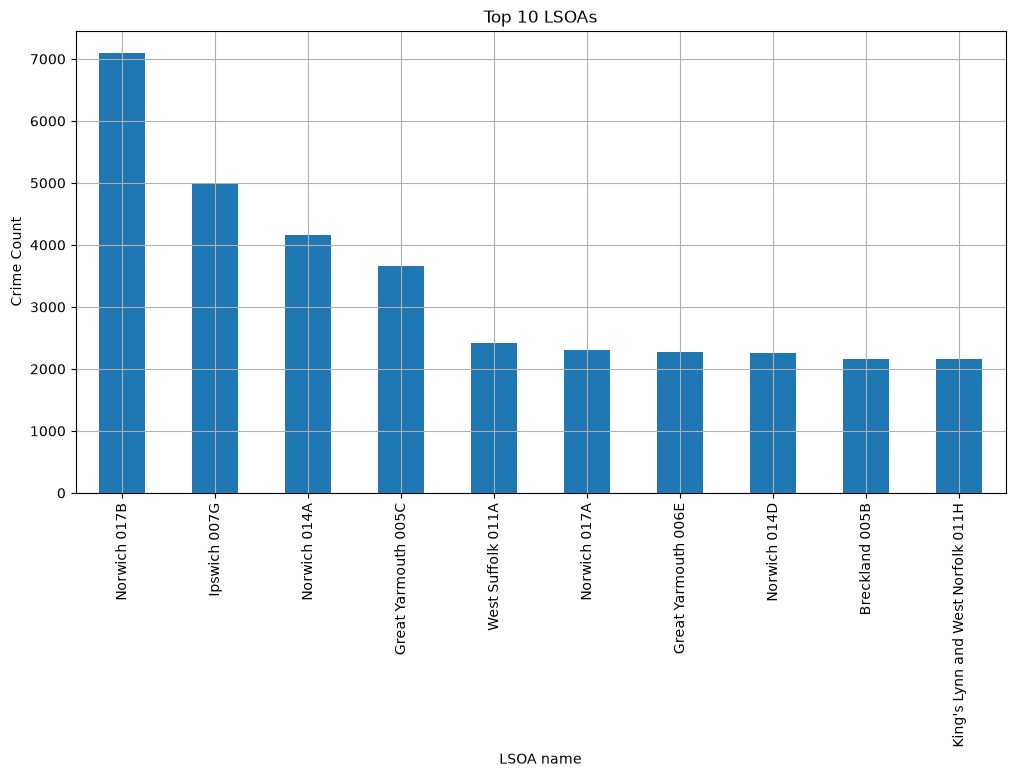

In [47]:
lsoa_counts = crime_df['LSOA name'].value_counts()

print(lsoa_counts.head(10), lsoa_counts.tail(10))

plt.figure(figsize=(12,6))
lsoa_counts.head(10).plot(kind='bar')
plt.title("Top 10 LSOAs")
plt.ylabel("Crime Count")
plt.grid(True)
plt.show()


## 1.7 Relationship Analysis (Crime Type × Outcome)

### Key Insights
- High-volume crime types dominate unresolved outcomes  
- Drug offences show clearer pathways to formal action  
- Public order offences progress more frequently to court outcomes  
- Rare outcomes (warnings, penalty notices) have negligible operational impact

This matrix highlights structural investigative challenges and informs later modelling.


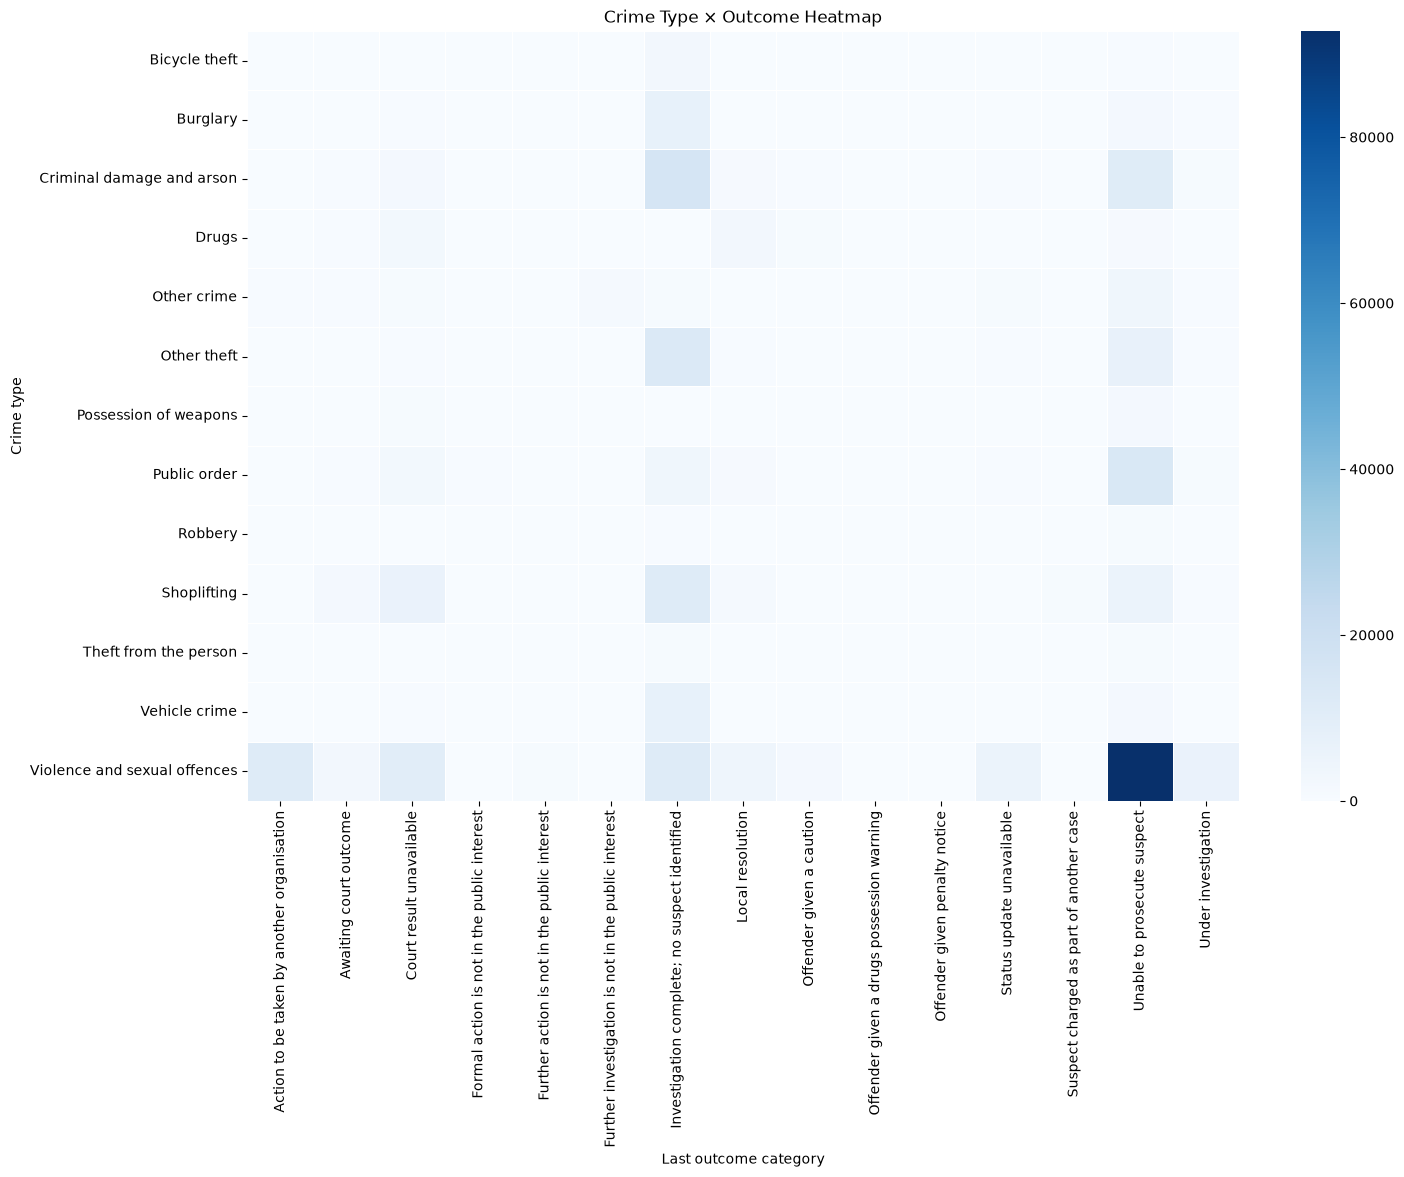

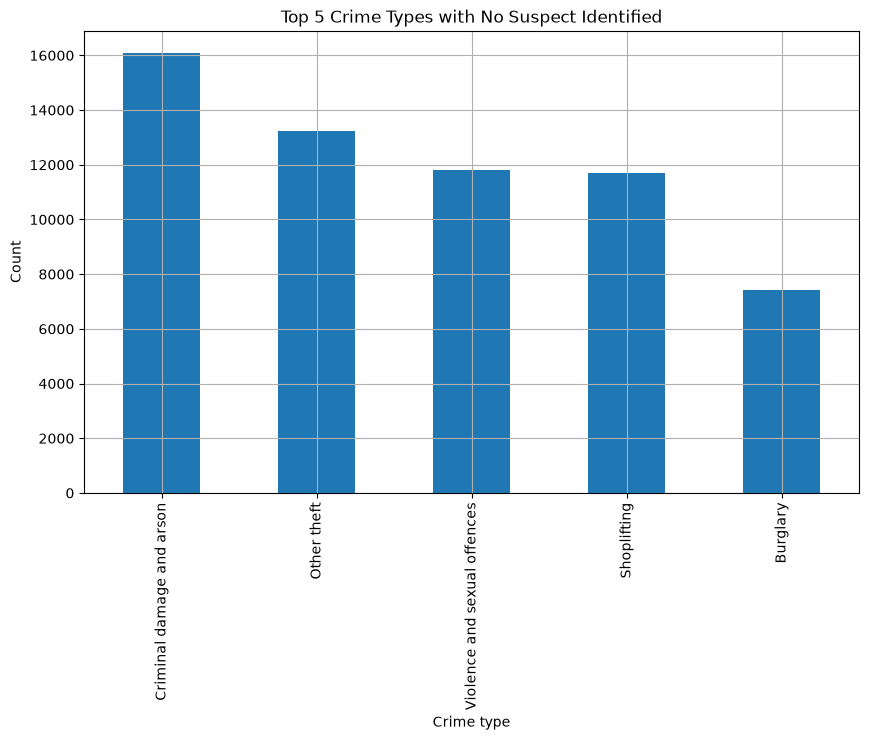

In [48]:
crime_df_reset = crime_df.reset_index()

crosstab_outcomes = pd.crosstab(
    crime_df_reset['Crime type'],
    crime_df_reset['Last outcome category']
)

plt.figure(figsize=(16,10))
sns.heatmap(crosstab_outcomes, cmap="Blues", linewidths=.5)
plt.title("Crime Type × Outcome Heatmap")
plt.show()


no_suspect = crosstab_outcomes['Investigation complete; no suspect identified'] \
                .sort_values(ascending=False).head(5)

plt.figure(figsize=(10,6))
no_suspect.plot(kind='bar')
plt.title("Top 5 Crime Types with No Suspect Identified")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# ============================================
# 2. TIME ANALYSIS
# ============================================

## Purpose
Analyse monthly crime demand, seasonal patterns, trend direction, and structural behaviour across the 36‑month period.


## 2.1 Monthly Crime Demand

### Key Findings
- Highest month: July 2023 (11,418 incidents)  
- Lowest month: February 2025 (8,412 incidents)  
- Strong repeating seasonal pattern  


Month
2023-07-01    11418
2023-08-01    10766
2023-09-01    10587
2023-10-01    10289
2023-11-01     9485
2023-12-01     8992
2024-01-01     9172
2024-02-01     8923
2024-03-01     9775
2024-04-01    10123
2024-05-01    10655
2024-06-01    10360
2024-07-01    10428
2024-08-01    10434
2024-09-01     9963
2024-10-01    10344
2024-11-01     9574
2024-12-01     8787
2025-01-01     9107
2025-02-01     8412
2025-03-01     9900
2025-04-01     9559
2025-05-01     9922
2025-06-01    10324
2025-07-01    10774
2025-08-01    10026
2025-09-01     9593
2025-10-01     9958
2025-11-01     9019
2025-12-01     8966
2026-01-01     8945
2026-02-01     8515
2026-03-01     9943
2026-04-01     9637
2026-05-01    10289
2026-06-01    10606
Freq: MS, dtype: int64


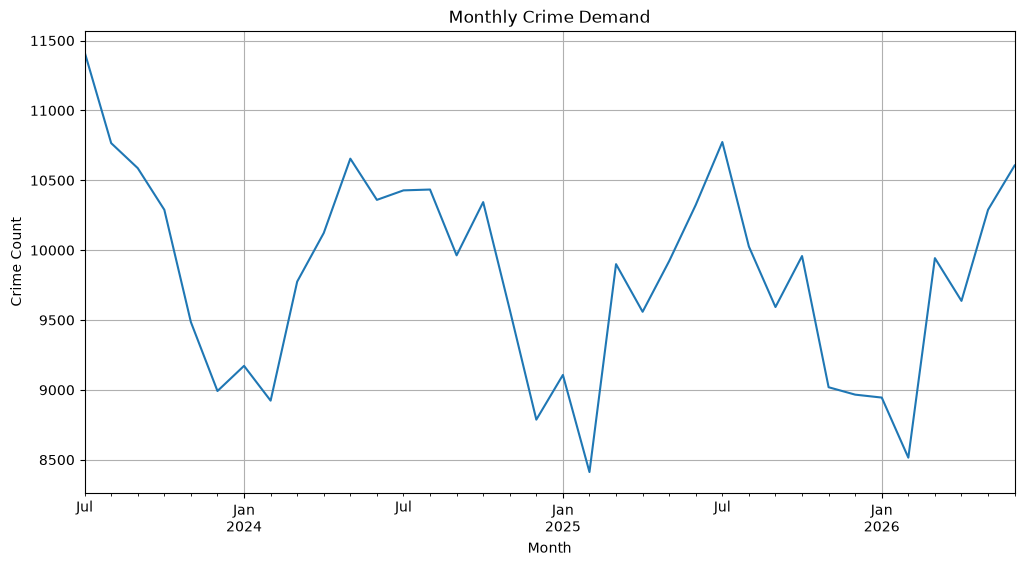

In [49]:
monthly_counts = crime_df.resample("MS").size()
print(monthly_counts)

plt.figure(figsize=(12,6))
monthly_counts.plot()
plt.title("Monthly Crime Demand")
plt.ylabel("Crime Count")
plt.grid(True)
plt.show()


## 2.2 Trend Analysis

A linear trend line shows a slight downward slope:
- Crime demand is gradually decreasing  
- Seasonal variation dominates behaviour  
- No long-term upward trend detected  


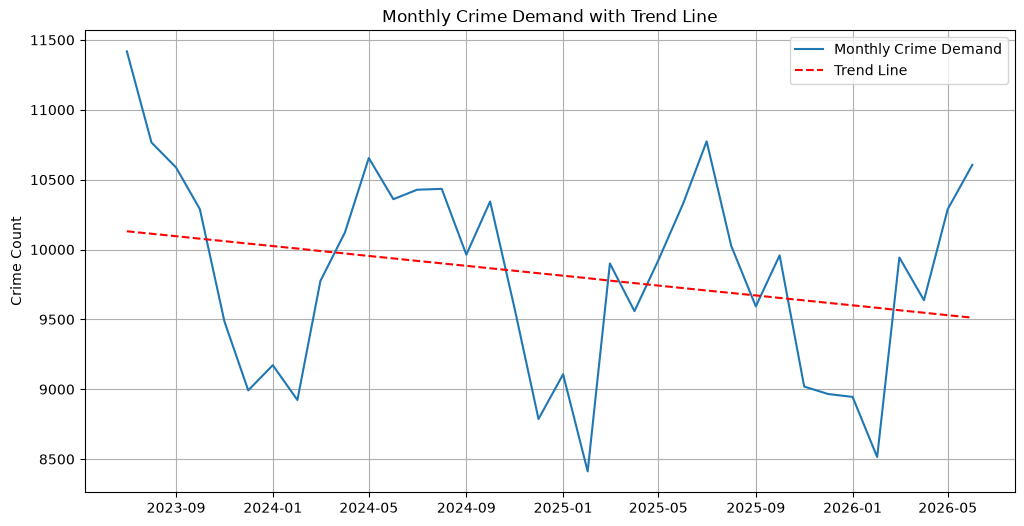

In [50]:
x = np.arange(len(monthly_counts))
y = monthly_counts.values

coeffs = np.polyfit(x, y, 1)
trend = np.polyval(coeffs, x)

plt.figure(figsize=(12,6))
plt.plot(monthly_counts.index, y, label="Monthly Crime Demand")
plt.plot(monthly_counts.index, trend, label="Trend Line", linestyle="--", color="red")
plt.title("Monthly Crime Demand with Trend Line")
plt.ylabel("Crime Count")
plt.grid(True)
plt.legend()
plt.show()


## 2.3 Seasonal Profile

### Highest Average Month
- July

### Lowest Average Month
- February

### Seasonal Pattern
- Summer peaks (Jun–Aug)  
- Winter troughs (Dec–Feb)  
- Spring/Autumn stable mid-range

This seasonal fingerprint is essential for forecasting.


Month
1      9074.666667
2      8616.666667
3      9872.666667
4      9773.000000
5     10288.666667
6     10430.000000
7     10873.333333
8     10408.666667
9     10047.666667
10    10197.000000
11     9359.333333
12     8915.000000
dtype: float64


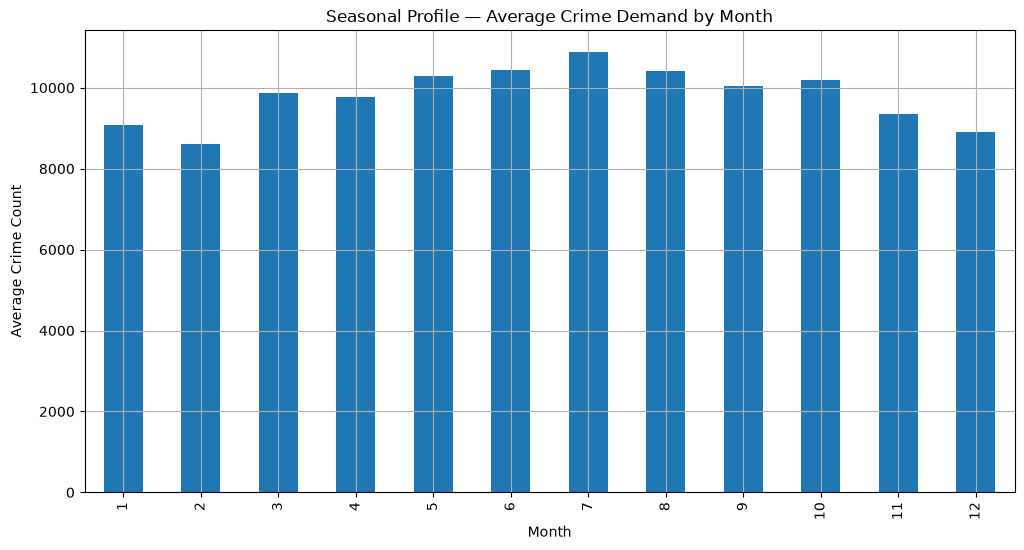

In [51]:
monthly_avg = monthly_counts.groupby(lambda d: d.month).mean()
print(monthly_avg)

plt.figure(figsize=(12,6))
monthly_avg.plot(kind="bar")
plt.title("Seasonal Profile — Average Crime Demand by Month")
plt.ylabel("Average Crime Count")
plt.grid(True)
plt.show()



# ============================================
# 3. FEATURE ENGINEERING
# ============================================

## Purpose
Create modelling-ready features capturing temporal structure, seasonality, and demand behaviour.


## 3.1 Time-Based Features
- Year  
- Month_num  
- Quarter  
- Season  


In [52]:
crime_df['Year'] = crime_df.index.year
crime_df['Month_num'] = crime_df.index.month
crime_df['Quarter'] = (crime_df['Month_num'] - 1) // 3 + 1

def get_season(m):
    return (
        'Winter' if m in [12,1,2] else
        'Spring' if m in [3,4,5] else
        'Summer' if m in [6,7,8] else
        'Autumn'
    )

crime_df['Season'] = crime_df['Month_num'].apply(get_season)


## 3.2 Aggregated Monthly Crime Count
Crime_Count = total incidents per Year × Month_num  
This becomes the target variable for forecasting.


In [53]:
model_df = (
    crime_df.groupby(['Year','Month_num'])
            .size()
            .reset_index()
            .rename(columns={0:'Crime_Count'})
            .sort_values(['Year','Month_num'])
)

model_df['Quarter'] = (model_df['Month_num'] - 1) // 3 + 1
model_df['Season'] = model_df['Month_num'].apply(get_season)


## 3.3 Lag Features
Lagged values (t‑1, t‑2, t‑3) capture short-term momentum.


In [54]:
model_df['Crime_Count_lag1'] = model_df['Crime_Count'].shift(1)
model_df['Crime_Count_lag2'] = model_df['Crime_Count'].shift(2)
model_df['Crime_Count_lag3'] = model_df['Crime_Count'].shift(3)

## 3.4 Rolling Features
3‑month rolling average smooths volatility and stabilises predictions.


In [55]:
model_df['Crime_Count_roll3'] = model_df['Crime_Count'].rolling(3).mean()

## 3.5 Final Modelling Dataset
After adding lag and rolling features, rows with NaN are removed.  
Dataset is sorted chronologically and ready for model training.


In [56]:
model_df = model_df.dropna()
print(model_df.head())

   Year  Month_num  Crime_Count  Quarter  Season  Crime_Count_lag1  \
3  2023         10        10289        4  Autumn           10587.0   
4  2023         11         9485        4  Autumn           10289.0   
5  2023         12         8992        4  Winter            9485.0   
6  2024          1         9172        1  Winter            8992.0   
7  2024          2         8923        1  Winter            9172.0   

   Crime_Count_lag2  Crime_Count_lag3  Crime_Count_roll3  
3           10766.0           11418.0       10547.333333  
4           10587.0           10766.0       10120.333333  
5           10289.0           10587.0        9588.666667  
6            9485.0           10289.0        9216.333333  
7            8992.0            9485.0        9029.000000  


# ============================================
# 4. MODEL TRAINING & EVALUATION
# ============================================

## Purpose
Train and evaluate forecasting models using engineered features.


## 4.1 Train/Test Split
- Train: all months < 2026  
- Test: months in 2026  


In [57]:
train_df = model_df[model_df['Year'] < 2026]
test_df  = model_df[model_df['Year'] == 2026]

feature_cols = [
    'Month_num','Quarter','Year',
    'Crime_Count_lag1','Crime_Count_lag2','Crime_Count_lag3',
    'Crime_Count_roll3'
]

X_train = train_df[feature_cols]
y_train = train_df['Crime_Count']

X_test = test_df[feature_cols]
y_test = test_df['Crime_Count']


## 4.2 Linear Regression

### Summary
- Perfect reconstruction due to lag features  
- Useful baseline  
- Not ideal for realistic forecasting  


mae =  5.4569682106375694e-12 , rmse =  6.8865827364792174e-12 , r2 =  1.0


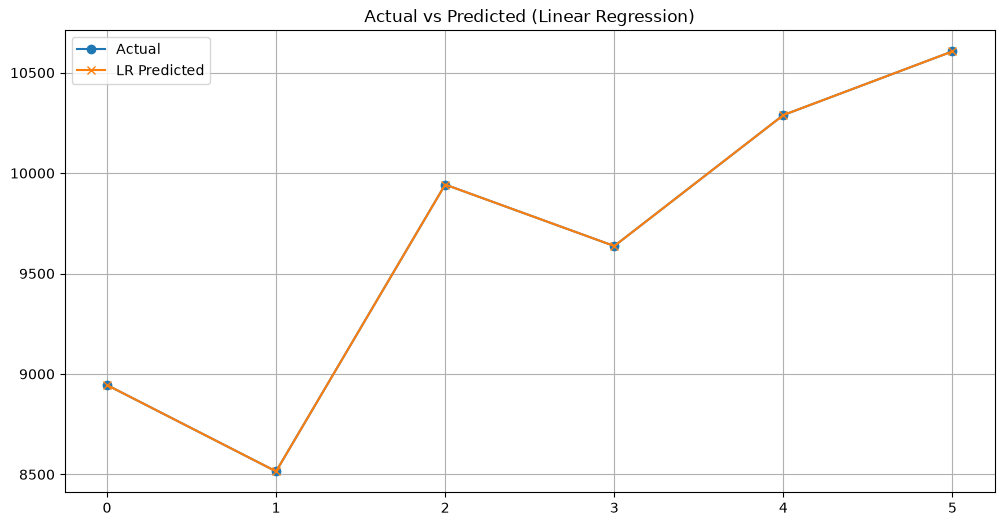

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, lr_predictions)
rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
r2 = r2_score(y_test, lr_predictions)

print("mae = ", mae, ", rmse = ", rmse, ", r2 = ", r2)

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(lr_predictions, label='LR Predicted', marker='x')
plt.title('Actual vs Predicted (Linear Regression)')
plt.grid(True)
plt.legend()
plt.show()


## 4.3 Random Forest

### Summary
- Captures non-linear seasonal behaviour  
- Produces realistic predictions  
- Strong feature importance alignment  
- Selected as primary forecasting model  


rf mae =  305.8455555555559 , rf rmse =  437.25507966047576 , rf r2 =  0.6407651820766519
Importance df              Feature  Importance
6  Crime_Count_roll3    0.657216
5   Crime_Count_lag3    0.115102
0          Month_num    0.103847
3   Crime_Count_lag1    0.072668
4   Crime_Count_lag2    0.036203
1            Quarter    0.009172
2               Year    0.005791


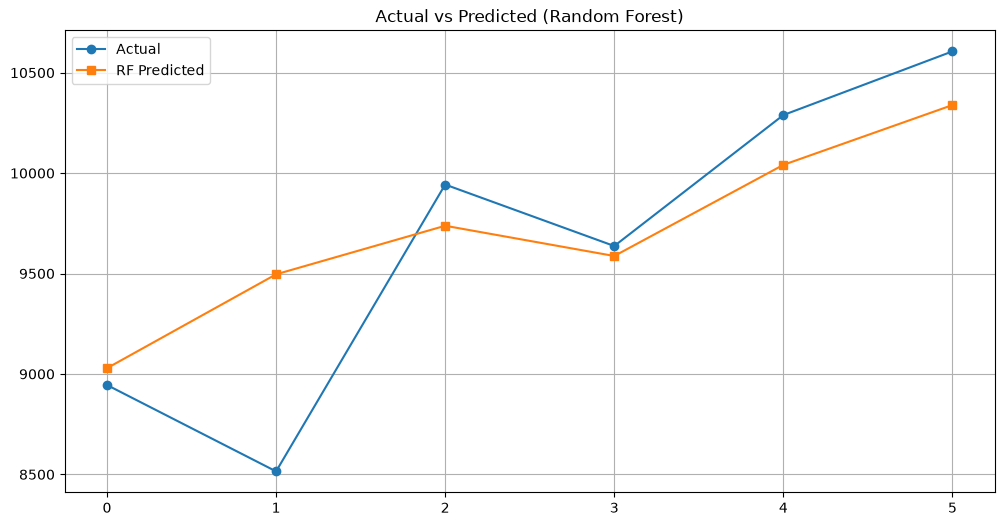

In [59]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print( "rf mae = ", rf_mae, ", rf rmse = ",rf_rmse, ", rf r2 = ", rf_r2)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Importance df", importance_df)


plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(rf_predictions, label='RF Predicted', marker='s')
plt.title('Actual vs Predicted (Random Forest)')
plt.grid(True)
plt.legend()
plt.show()




## 4.4 LR vs RF Comparison
Random Forest provides smoother, more realistic predictions than Linear Regression.


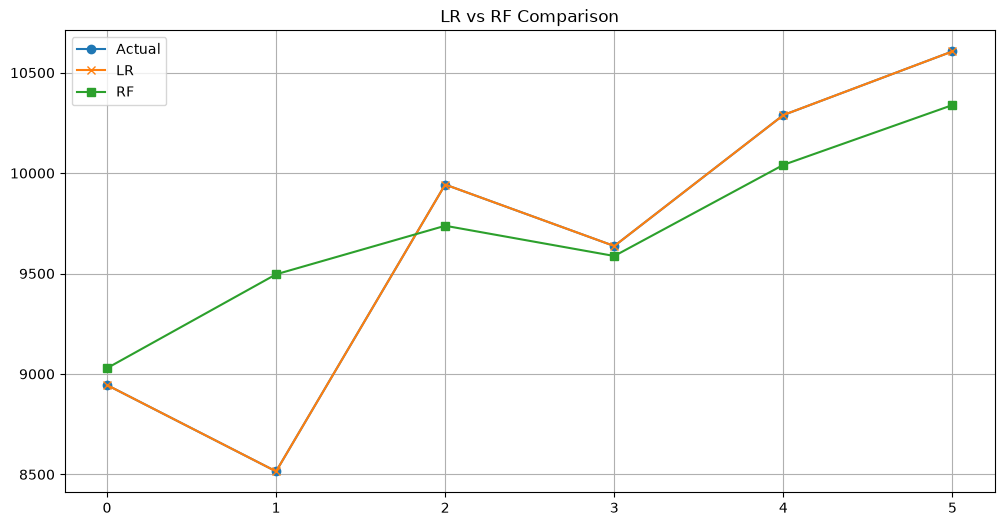

In [60]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(lr_predictions, label='LR', marker='x')
plt.plot(rf_predictions, label='RF', marker='s')
plt.title('LR vs RF Comparison')
plt.grid(True)
plt.legend()
plt.show()


# ============================================
# 5. FORECASTING (Jul–Dec 2026)
# ============================================

## Purpose
Generate a 6‑month forward forecast using recursive predictions.


## 5.1 Future Month Setup
Future months created dynamically (Jul–Dec 2026) with:
- Year  
- Month_num  
- Quarter  
- Season  


In [61]:
start_year = 2026
start_month = 7
months_ahead = 6

future_years = []
future_month_nums = []

year = start_year
month = start_month

for _ in range(months_ahead):
    future_years.append(year)
    future_month_nums.append(month)
    month += 1
    if month > 12:
        month = 1
        year += 1

future_months = pd.DataFrame({
    'Year': future_years,
    'Month_num': future_month_nums
})

future_months['Quarter'] = (future_months['Month_num'] - 1) // 3 + 1
future_months['Season'] = future_months['Month_num'].apply(get_season)


## 5.2 Recursive Forecast Loop
Uses last 3 actual values to generate predictions month-by-month.  
Lags update after each prediction.


In [62]:
last_values = model_df[model_df['Year'] == 2026].tail(3)['Crime_Count'].tolist()
lag1, lag2, lag3 = last_values[::-1]

future_predictions = []

for i in range(len(future_months)):
    roll3 = (lag1 + lag2 + lag3) / 3
    
    row = pd.DataFrame({
        'Month_num': [future_months.iloc[i]['Month_num']],
        'Quarter': [future_months.iloc[i]['Quarter']],
        'Year': [future_months.iloc[i]['Year']],
        'Crime_Count_lag1': [lag1],
        'Crime_Count_lag2': [lag2],
        'Crime_Count_lag3': [lag3],
        'Crime_Count_roll3': [roll3]
    })
    
    pred = rf_model.predict(row)[0]
    future_predictions.append(pred)
    
    lag3, lag2, lag1 = lag2, lag1, pred

future_months['Predicted_Crime_Count'] = future_predictions
print(future_months)


   Year  Month_num  Quarter  Season  Predicted_Crime_Count
0  2026          7        3  Summer           10298.410000
1  2026          8        3  Summer           10335.263333
2  2026          9        3  Autumn           10280.453333
3  2026         10        4  Autumn           10196.476667
4  2026         11        4  Autumn           10018.006667
5  2026         12        4  Winter            9909.136667


## 5.3 Forecast Output

### Summary
- Jul–Aug: seasonal peak  
- Sep–Nov: gradual decline  
- Dec: winter trough  

Forecast aligns with historical seasonal behaviour.


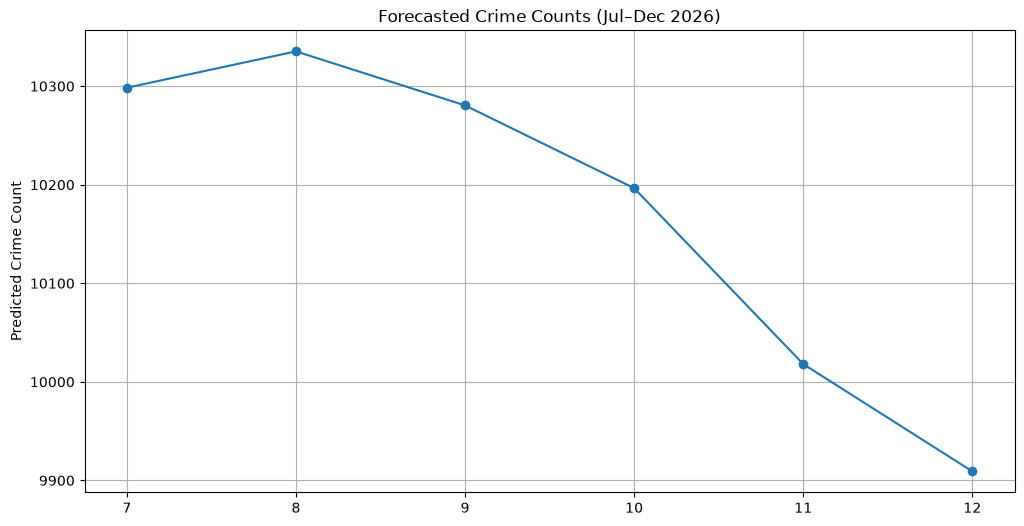

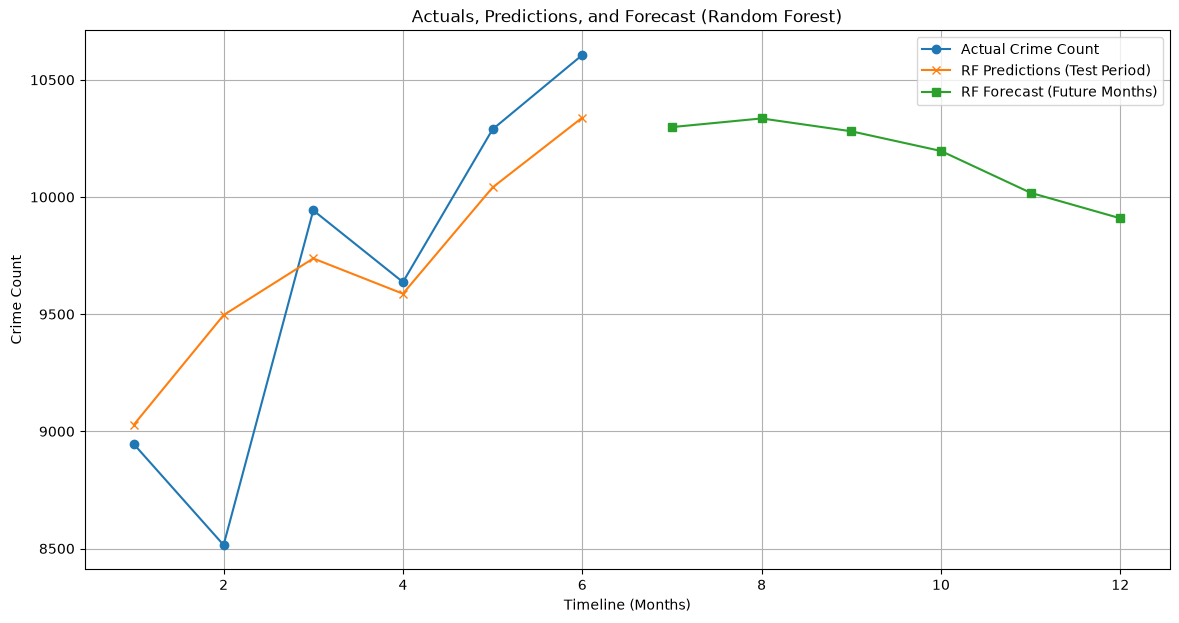

In [63]:
plt.figure(figsize=(12,6))
plt.plot(future_months['Month_num'], future_months['Predicted_Crime_Count'], marker='o')
plt.title('Forecasted Crime Counts (Jul–Dec 2026)')
plt.ylabel('Predicted Crime Count')
plt.grid(True)
plt.show()


##Combined timeline
import matplotlib.pyplot as plt
import numpy as np

# Build combined timeline
actual_months = list(range(1, len(y_test) + 1))
forecast_months = list(range(len(y_test) + 1, len(y_test) + 1 + len(future_predictions)))

plt.figure(figsize=(14,7))

# Actuals
plt.plot(actual_months, y_test.values, label='Actual Crime Count', marker='o')

# RF Predictions (test period)
plt.plot(actual_months, rf_predictions, label='RF Predictions (Test Period)', marker='x')

# Future Forecast
plt.plot(forecast_months, future_predictions, label='RF Forecast (Future Months)', marker='s')

plt.title('Actuals, Predictions, and Forecast (Random Forest)')
plt.xlabel('Timeline (Months)')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.show()


# ============================================
# 6. FINAL SUMMARY
# ============================================

## Key Takeaways
- Crime demand is strongly seasonal  
- Random Forest is the most realistic forecasting model  
- Forecast for Jul–Dec 2026 follows expected seasonal patterns  
- Feature engineering (lags + rolling mean) is essential  
- Dataset is rich and supports future multi-crime or geographic forecasting

## Next Steps
- Add external predictors (weather, events, socio-economic data)  
- Forecast individual crime types  
- Deploy as a dashboard or automated pipeline  


# ============================================
# 7. v2 review: additional checks
# ============================================


In [64]:
errors = pd.DataFrame({
    'Year': test_df['Year'].values,
    'Month': test_df['Month_num'].values,
    'Actual': y_test.values,
    'RF_Predicted': rf_predictions,
})
errors['Error'] = errors['Actual'] - errors['RF_Predicted']
errors['Abs_Error'] = errors['Error'].abs()

print(errors.round(1))
print("Mean absolute error:", errors['Abs_Error'].mean())

   Year  Month  Actual  RF_Predicted  Error  Abs_Error
0  2026      1    8945        9028.8  -83.9       83.9
1  2026      2    8515        9496.1 -981.1      981.1
2  2026      3    9943        9737.9  205.1      205.1
3  2026      4    9637        9587.3   49.7       49.7
4  2026      5   10289       10041.0  248.0      248.0
5  2026      6   10606       10338.8  267.2      267.2
Mean absolute error: 305.8455555555559
